In [2]:
import numpy as np
import matplotlib.pyplot as plt

import reservoirpy
from reservoirpy.mat_gen import uniform
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import spectral_radius

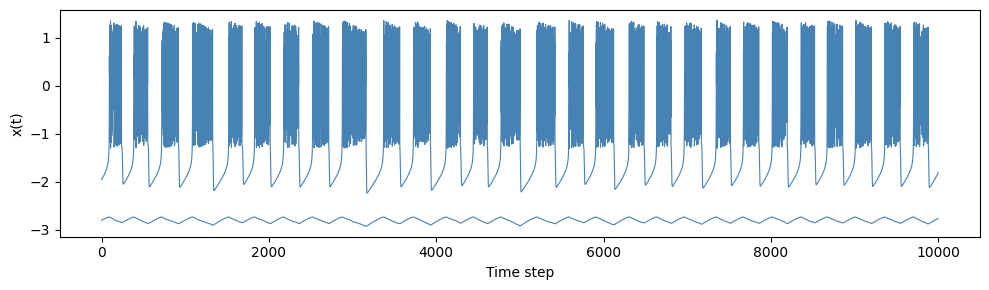

In [7]:
dataset = np.loadtxt('../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[: ,]

# Visualize the chaotic time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset, color='steelblue', linewidth=0.8)
ax.set_xlabel('Time step')
ax.set_ylabel('x(t)')
plt.tight_layout()
plt.show()

Train interval : [0 : 2000]
Test interval  : [5000 : 7000]
Warmup length  : 200
Pred. length   : 1800
MSE   : 0.0354954547
RMSE  : 0.1884023746
NRMSE : 0.7951257660


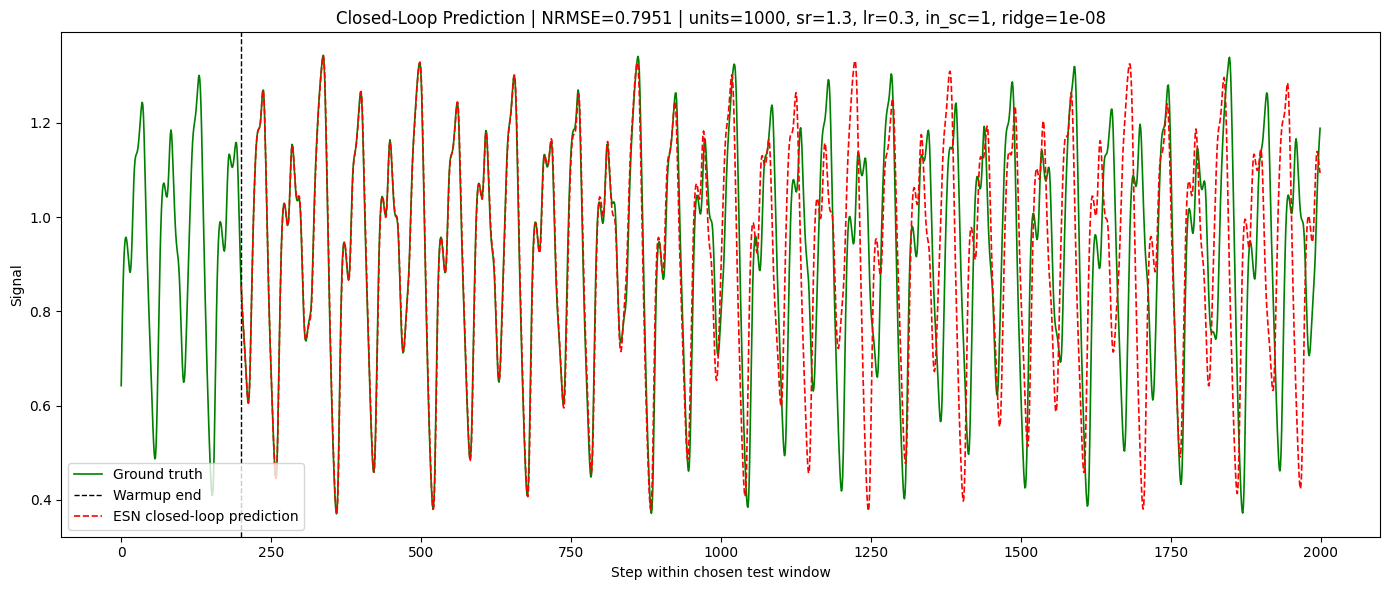

In [6]:
# USER PARAMETERS
train_len = 2000   # training uses data[0:train_len]
test_start = 5000  # start index of test window in the full dataset
test_len = 2000    # total length of chosen test window
warmup_len = 200   # first part of test window used for synchronization
ridge_coef = 1e-8

res_units = 1000
leak_rate = 0.3
spectral_radius = 1.3
input_scaling = 1
seed = 42

# DATA PREPARATION
data = dataset.reshape(-1, 1)
# X[t] = data[t], Y[t] = data[t+1]
X = data[:-1]
Y = data[1:]

# Training split
X_train = X[:train_len]
Y_train = Y[:train_len]

# Test window
X_test = X[test_start:test_start + test_len]
Y_test = Y[test_start:test_start + test_len]

# ESN DEFINITION
reservoir = Reservoir(
    units=res_units,
    lr=leak_rate,
    W=uniform(low=-0.5, high=0.5, connectivity=1.0, sr=spectral_radius),
    Win=uniform(low=-0.5 * input_scaling,
                high=0.5 * input_scaling, connectivity=1.0),
    bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
    activation="tanh",
    seed=seed
)

readout = Ridge(ridge=ridge_coef)
esn = reservoir >> readout

# TRAINING
esn.fit(X_train, Y_train, warmup=100)

# TESTING ON AN ARBITRARY WINDOW
# 1) reset ESN
# 2) warm up with the first warmup_len true samples of the test window
# 3) start closed-loop prediction from the next point
# 4) compute error only on the prediction portion
esn.reset()

# Synchronize reservoir with true data from the chosen test window
if warmup_len > 0:
    esn.run(X_test[:warmup_len])

# Closed-loop prediction starts immediately after warmup
pred_len = test_len - warmup_len
Y_pred = []

current_input = X_test[warmup_len:warmup_len + 1]  # first seed after warmup

for _ in range(pred_len):
    pred = esn.run(current_input)
    pred = np.asarray(pred).reshape(1, -1)
    Y_pred.append(pred[0, 0])
    current_input = pred  # closed-loop feedback

Y_pred = np.array(Y_pred)

# Ground truth aligned with prediction interval
Y_true = Y_test[warmup_len:warmup_len + pred_len, 0]

# ERROR METRICS
mse = np.mean((Y_true - Y_pred) ** 2)
rmse = np.sqrt(mse)
nrmse = rmse / np.std(Y_true)

print(f"Train interval : [0 : {train_len}]")
print(f"Test interval  : [{test_start} : {test_start + test_len}]")
print(f"Warmup length  : {warmup_len}")
print(f"Pred. length   : {pred_len}")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse:.10f}")

# VISUALIZATION
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test[:, 0], c='green', label="Ground truth", linewidth=1.2)
ax.axvline(warmup_len, linestyle="--", c='k', linewidth=1.0, label="Warmup end")
ax.plot(np.arange(warmup_len, warmup_len + pred_len), Y_pred, linestyle="--", c='red', linewidth=1.2, label="ESN closed-loop prediction")
ax.set_title(
    f"Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"units={res_units}, sr={spectral_radius}, "
    f"lr={leak_rate}, in_sc={input_scaling}, "
    f"ridge={ridge_coef:.0e}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()